# Fractal Pareidolia + DAT Priming — Results Analysis
**Images:** 161 fractal images (FD 1.35 + FD 1.7)  
**Design:** 3 temperatures × 10 runs per image  
**Protocol:** Fractal percept prompt → DAT prompt (same thread)


In [1]:
import json
from pathlib import Path
from collections import defaultdict

# =============================================================================
# CONFIGURATION
# =============================================================================
TEMPERATURES = [0.0, 1.0, 1.5]
NUM_RUNS = 10

# Paths
ROOT = Path("../../new-FD-images")
IMAGE_DIRS = [ROOT / "FD135", ROOT / "FD17"]
MAIN_OUTPUT = Path("main_results.jsonl")


def get_all_images():
    """Returns a list of all image Path objects."""
    images = []
    for d in IMAGE_DIRS:
        if d.exists():
            images.extend(d.glob("*.png"))
            images.extend(d.glob("*.jpg"))
    return images


def main():
    print("Analyzing missing data in detail...\n")
    images = get_all_images()

    if not images:
        print("! No images found! Check your folder paths.")
        return

    # 1. Generate all EXPECTED combinations
    # Tuple format: (temperature, filename, run_id)
    expected_main = set()
    image_to_folder = {}

    for img in images:
        image_to_folder[img.name] = img.parent.name
        for temp in TEMPERATURES:
            for run_id in range(1, NUM_RUNS + 1):
                expected_main.add((temp, img.name, run_id))

    # 2. Read COMPLETED combinations from file
    completed_main = set()
    if MAIN_OUTPUT.exists():
        with open(MAIN_OUTPUT, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    record = json.loads(line)
                    completed_main.add((record["temperature"], record["file"], record["run_id"]))
                except json.JSONDecodeError:
                    pass

    # 3. Find MISSING combinations (Expected - Completed)
    missing_main = expected_main - completed_main

    print("-" * 50)
    print(f"Total Images Found:    {len(images)}")
    print(f"Total Expected Runs:   {len(expected_main)}")
    print(f"Total Completed Runs:  {len(completed_main)}")
    print(f"Total Missing Runs:    {len(missing_main)}")
    print("-" * 50)

    if len(missing_main) == 0:
        print("All main experiment tests are 100% completed!")
        return

    print("\n>>> DETAILED LIST OF MISSING TESTS <<<\n")

    # Group the missing data by image for readable output
    missing_by_image = defaultdict(lambda: defaultdict(list))
    for temp, img_name, run_id in missing_main:
        missing_by_image[img_name][temp].append(run_id)

    # Print the grouped missing data
    for img_name, temp_dict in missing_by_image.items():
        folder = image_to_folder.get(img_name, "Unknown")
        print(f"[Image]: {img_name}  |  [Folder]: {folder}")

        for temp in sorted(temp_dict.keys()):
            runs = sorted(temp_dict[temp])
            print(f"    - Temp {temp}: Missing Runs -> {runs}")
        print("-" * 40)


if __name__ == "__main__":
    main()

Analyzing missing data in detail...

--------------------------------------------------
Total Images Found:    161
Total Expected Runs:   4830
Total Completed Runs:  4765
Total Missing Runs:    65
--------------------------------------------------

>>> DETAILED LIST OF MISSING TESTS <<<

[Image]: FD_1.7_0.png  |  [Folder]: FD17
    - Temp 1.5: Missing Runs -> [6, 9]
----------------------------------------
[Image]: FD_1.35_5.png  |  [Folder]: FD135
    - Temp 1.5: Missing Runs -> [4]
----------------------------------------
[Image]: FD_1.35_66.png  |  [Folder]: FD135
    - Temp 1.5: Missing Runs -> [2]
----------------------------------------
[Image]: FD_1.7_43.png  |  [Folder]: FD17
    - Temp 1.0: Missing Runs -> [7]
    - Temp 1.5: Missing Runs -> [7, 10]
----------------------------------------
[Image]: FD_1.7_77.png  |  [Folder]: FD17
    - Temp 1.5: Missing Runs -> [9, 10]
----------------------------------------
[Image]: FD_1.35_79.png  |  [Folder]: FD135
    - Temp 1.0: Missing

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter, defaultdict
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
BLUE   = '#378ADD'
GRAY   = '#888780'
PINK   = '#D4537E'

# ── Load data ──
baseline = [json.loads(l) for l in open('dat_baseline_results.jsonl')]
main     = [json.loads(l) for l in open('main_results.jsonl')]

print(f"Baseline: {len(baseline)} records")
print(f"Main:     {len(main)} records")
print(f"Total:    {len(baseline) + len(main)} records")


Baseline: 30 records
Main:     4765 records
Total:    4795 records


## 1. Data preparation

In [9]:
rows = []
for r in main:
    fp = r.get('fractal_parsed')
    dp = r.get('dat_parsed') or {}

    # Normalise fractal_parsed
    if isinstance(fp, dict):
        percepts = fp.get('percepts', [])
    elif isinstance(fp, list):
        percepts = fp
    else:
        percepts = []

    # Normalise words — Qwen sometimes returns [{"word": "cat"}] instead of ["cat"]
    raw_words = dp.get('words', []) if isinstance(dp, dict) else []
    words = []
    for w in raw_words:
        if isinstance(w, str):
            words.append(w)
        elif isinstance(w, dict):
            for v in w.values():
                if isinstance(v, str):
                    words.append(v)
                    break

    rows.append({
        'temperature':    r['temperature'],
        'temp_label':     r['temp_label'],
        'file':           r['file'],
        'fd':             r['fd'],
        'run_id':         r['run_id'],
        'n_percepts':     len(percepts),
        'percept_labels': [p.get('label', '').lower() for p in percepts if isinstance(p, dict)],
        'confidences':    [p.get('confidence_present', 0) for p in percepts if isinstance(p, dict)],
        'dat_words':      [w.lower() for w in words],
        'n_dat_words':    len(words),
        'ms_fractal':     r.get('ms_fractal'),
        'ms_dat':         r.get('ms_dat'),
    })

## 2. Percept count by fractal dimension × temperature

Baseline: 30 records
Main:     4765 records
Total:    4795 records

Main DataFrame:     (4765, 12)
Baseline DataFrame: (30, 5)

                   count  mean   std  min  25%  50%  75%   max
fd    temperature                                             
FD135 0.0          810.0  1.37  1.79  0.0  0.0  1.0  1.0  11.0
      1.0          808.0  1.18  1.63  0.0  0.0  1.0  1.0  15.0
      1.5          785.0  0.09  0.34  0.0  0.0  0.0  0.0   3.0
FD17  0.0          799.0  0.00  0.05  0.0  0.0  0.0  0.0   1.0
      1.0          792.0  0.57  1.10  0.0  0.0  0.0  1.0   8.0
      1.5          771.0  0.11  0.39  0.0  0.0  0.0  0.0   4.0


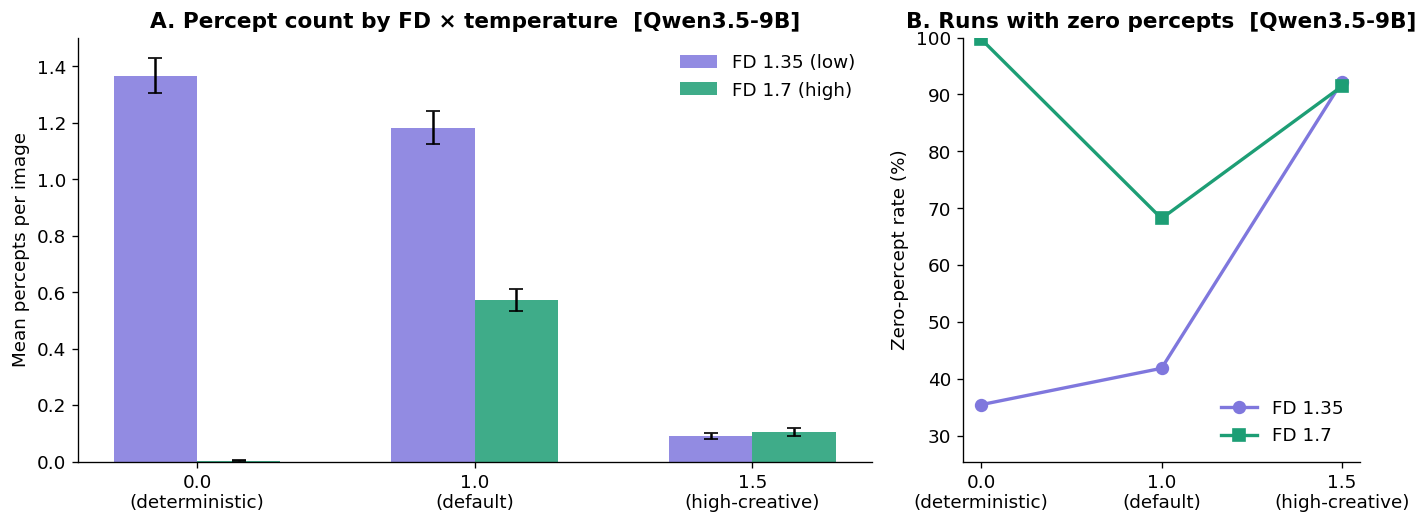


FD 1.35 vs FD 1.7 (image-level means):
  FD 1.35: 0.888 ± 0.446  (n=81)
  FD 1.7:  0.227 ± 0.128  (n=80)
  t = 12.767, p = 0.0000


In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter, defaultdict
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
BLUE   = '#378ADD'
GRAY   = '#888780'
PINK   = '#D4537E'

SAVE_DIR = (
    '/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/'
    'new-FD-images/results/Qwen3.5-9B/'
)

# ── Load data ──
baseline = [json.loads(l) for l in open('dat_baseline_results.jsonl')]
main     = [json.loads(l) for l in open('main_results.jsonl')]

print(f"Baseline: {len(baseline)} records")
print(f"Main:     {len(main)} records")
print(f"Total:    {len(baseline) + len(main)} records")

# ── Flatten main results ──
rows = []
for r in main:
    fp = r.get('fractal_parsed')
    dp = r.get('dat_parsed') or {}

    # Normalise fractal_parsed
    if isinstance(fp, dict):
        percepts = fp.get('percepts', [])
    elif isinstance(fp, list):
        percepts = fp
    else:
        percepts = []

    # Normalise words — Qwen sometimes returns [{"word": "cat"}] instead of ["cat"]
    raw_words = dp.get('words', []) if isinstance(dp, dict) else []
    words = []
    for w in raw_words:
        if isinstance(w, str):
            words.append(w)
        elif isinstance(w, dict):
            for v in w.values():
                if isinstance(v, str):
                    words.append(v)
                    break

    rows.append({
        'temperature':    r['temperature'],
        'temp_label':     r['temp_label'],
        'file':           r['file'],
        'fd':             r['fd'],
        'run_id':         r['run_id'],
        'n_percepts':     len(percepts),
        'percept_labels': [p.get('label', '').lower() for p in percepts if isinstance(p, dict)],
        'confidences':    [p.get('confidence_present', 0) for p in percepts if isinstance(p, dict)],
        'dat_words':      [w.lower() for w in words],
        'n_dat_words':    len(words),
        'ms_fractal':     r.get('ms_fractal'),
        'ms_dat':         r.get('ms_dat'),
    })

df = pd.DataFrame(rows)

# ── Flatten baseline ──
b_rows = []
for r in baseline:
    dp = r.get('dat_parsed') or {}
    raw_words = dp.get('words', []) if isinstance(dp, dict) else []
    words = []
    for w in raw_words:
        if isinstance(w, str):
            words.append(w)
        elif isinstance(w, dict):
            for v in w.values():
                if isinstance(v, str):
                    words.append(v)
                    break
    b_rows.append({
        'temperature': r['temperature'],
        'temp_label':  r['temp_label'],
        'run_id':      r['run_id'],
        'dat_words':   [w.lower() for w in words],
        'ms':          r['ms'],
    })

df_b = pd.DataFrame(b_rows)

print(f"\nMain DataFrame:     {df.shape}")
print(f"Baseline DataFrame: {df_b.shape}")
print()
print(df.groupby(['fd', 'temperature'])['n_percepts'].describe().round(2))

# ── Fig 1: Percepts by FD × temperature ──
temps       = sorted(df['temperature'].unique())
temp_names  = {0.0: '0.0\n(deterministic)', 1.0: '1.0\n(default)', 1.5: '1.5\n(high-creative)'}
tick_labels = [temp_names.get(t, str(t)) for t in temps]
x = np.arange(len(temps))
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={'width_ratios': [2, 1]})

# Panel A: grouped bar
ax = axes[0]
means_135 = [df[(df.fd=='FD135') & (df.temperature==t)]['n_percepts'].mean() for t in temps]
means_17  = [df[(df.fd=='FD17')  & (df.temperature==t)]['n_percepts'].mean() for t in temps]
sems_135  = [df[(df.fd=='FD135') & (df.temperature==t)]['n_percepts'].sem()  for t in temps]
sems_17   = [df[(df.fd=='FD17')  & (df.temperature==t)]['n_percepts'].sem()  for t in temps]

ax.bar(x - w/2, means_135, w, yerr=sems_135, label='FD 1.35 (low)', color=PURPLE, alpha=0.85, capsize=4)
ax.bar(x + w/2, means_17,  w, yerr=sems_17,  label='FD 1.7 (high)', color=TEAL,   alpha=0.85, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(tick_labels)
ax.set_ylabel('Mean percepts per image')
ax.set_title('A. Percept count by FD × temperature  [Qwen3.5-9B]')
ax.legend(frameon=False)

# Panel B: zero-percept rate
ax = axes[1]
zero_135 = [100 * (df[(df.fd=='FD135') & (df.temperature==t)]['n_percepts'] == 0).mean() for t in temps]
zero_17  = [100 * (df[(df.fd=='FD17')  & (df.temperature==t)]['n_percepts'] == 0).mean() for t in temps]

ax.plot(tick_labels, zero_135, 'o-', color=PURPLE, label='FD 1.35', linewidth=2, markersize=7)
ax.plot(tick_labels, zero_17,  's-', color=TEAL,   label='FD 1.7',  linewidth=2, markersize=7)
ax.set_ylabel('Zero-percept rate (%)')
ax.set_title('B. Runs with zero percepts  [Qwen3.5-9B]')
ax.legend(frameon=False)

valid_zeros = [v for v in zero_135 + zero_17 if not np.isnan(v)]
if valid_zeros:
    ax.set_ylim(max(0, min(valid_zeros) - 10), min(100, max(valid_zeros) + 10))

plt.tight_layout()
import os; os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(SAVE_DIR + 'fig1_percepts_by_fd_temp.png', dpi=300, bbox_inches='tight')
plt.show()

# ── t-test ──
img_means  = df.groupby(['fd', 'file'])['n_percepts'].mean().reset_index()
fd135_vals = img_means[img_means.fd == 'FD135']['n_percepts']
fd17_vals  = img_means[img_means.fd == 'FD17' ]['n_percepts']

if len(fd135_vals) > 1 and len(fd17_vals) > 1:
    t_stat, p_val = stats.ttest_ind(fd135_vals, fd17_vals)
    print(f"\nFD 1.35 vs FD 1.7 (image-level means):")
    print(f"  FD 1.35: {fd135_vals.mean():.3f} ± {fd135_vals.std():.3f}  (n={len(fd135_vals)})")
    print(f"  FD 1.7:  {fd17_vals.mean():.3f} ± {fd17_vals.std():.3f}  (n={len(fd17_vals)})")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}")
else:
    print("\nNot enough data for t-test.")
    print(f"  FD135: {len(fd135_vals)} images,  FD17: {len(fd17_vals)} images")

## 3. What does the model see? — Top percept labels

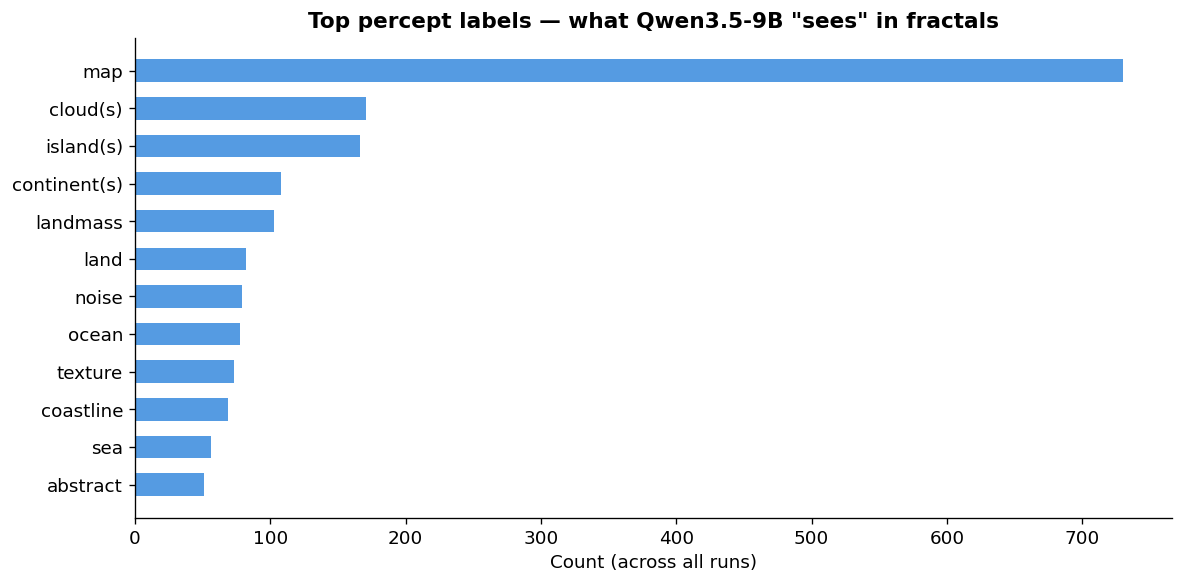


Total percept instances: 2635
Unique labels (raw):     359
Unique labels (merged):  336

Top 12:
  map                  730
  cloud(s)             171
  island(s)            166
  continent(s)         108
  landmass             103
  land                 82
  noise                79
  ocean                78
  texture              73
  coastline            69
  sea                  56
  abstract             51


In [14]:
# ── Fig 2: Top percept labels ──
all_labels = []
for labels in df['percept_labels']:
    all_labels.extend(labels)

label_counts = Counter(all_labels)

# Plural/singular merge
merged = Counter()
for label, count in label_counts.items():
    key = label.rstrip('s') if label.endswith('s') and label[:-1] in label_counts else label
    # manual merges
    if label in ('cloud', 'clouds'):           key = 'cloud(s)'
    elif label in ('island', 'islands'):       key = 'island(s)'
    elif label in ('blob', 'blobs'):           key = 'blob(s)'
    elif label in ('continent', 'continents'): key = 'continent(s)'
    elif label in ('ink', 'inkblot'):          key = 'ink/inkblot'
    elif label in ('shape', 'shapes'):         key = 'shape(s)'
    elif label in ('shadow', 'shadows'):       key = 'shadow(s)'
    elif label in ('figure', 'figures'):       key = 'figure(s)'
    elif label in ('pattern', 'patterns'):     key = 'pattern(s)'
    merged[key] += count

top = merged.most_common(12)
labels_sorted = [l for l, c in reversed(top)]
counts_sorted = [c for l, c in reversed(top)]

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CORAL if l == 'face' else BLUE for l in labels_sorted]
bars = ax.barh(labels_sorted, counts_sorted, color=colors, alpha=0.85, height=0.6)
ax.set_xlabel('Count (across all runs)')
ax.set_title('Top percept labels — what Qwen3.5-9B "sees" in fractals')

# Annotate face bar if present
for bar, label in zip(bars, labels_sorted):
    if label == 'face':
        ax.annotate('← classic pareidolia target',
                    xy=(bar.get_width() + max(counts_sorted) * 0.02,
                        bar.get_y() + bar.get_height() / 2),
                    fontsize=10, color=CORAL, va='center')

plt.tight_layout()
import os; os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(SAVE_DIR + 'fig2_top_percepts.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal percept instances: {sum(label_counts.values())}")
print(f"Unique labels (raw):     {len(label_counts)}")
print(f"Unique labels (merged):  {len(merged)}")
print(f"\nTop 12:")
for label, count in top:
    print(f"  {label:<20} {count}")

## 4. Percept label distribution by fractal dimension

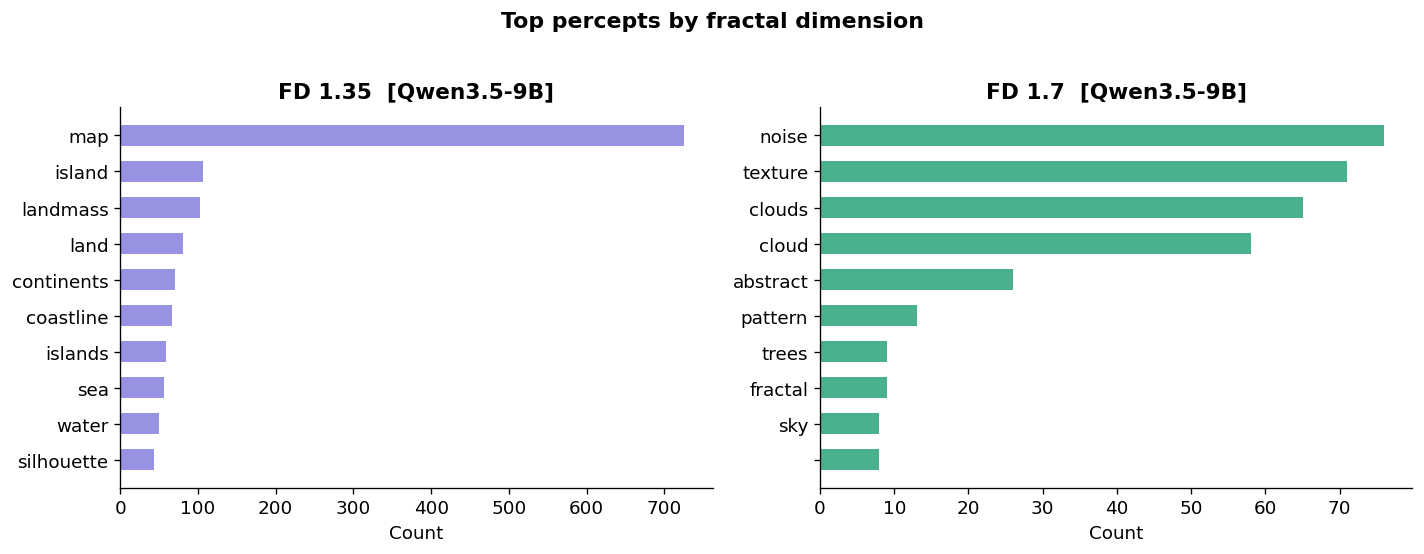

In [16]:
# ── Fig 3: Top percepts by fractal dimension ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, fd, color, title in zip(axes, ['FD135', 'FD17'], [PURPLE, TEAL], ['FD 1.35', 'FD 1.7']):
    sub = df[df.fd == fd]
    labels_flat = [l for ls in sub['percept_labels'] for l in ls]
    top = Counter(labels_flat).most_common(10)

    if not top:
        ax.text(0.5, 0.5, 'No percepts', ha='center', va='center',
                transform=ax.transAxes, color=GRAY, fontsize=12)
        ax.set_title(f'{title}  [Qwen3.5-9B]')
        ax.set_xlabel('Count')
        continue

    ax.barh([l for l, c in reversed(top)],
            [c for l, c in reversed(top)],
            color=color, alpha=0.8, height=0.6)
    ax.set_title(f'{title}  [Qwen3.5-9B]')
    ax.set_xlabel('Count')

plt.suptitle('Top percepts by fractal dimension', fontweight='bold', y=1.02)
plt.tight_layout()
import os; os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(SAVE_DIR + 'fig3_percepts_by_fd.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Confidence distribution

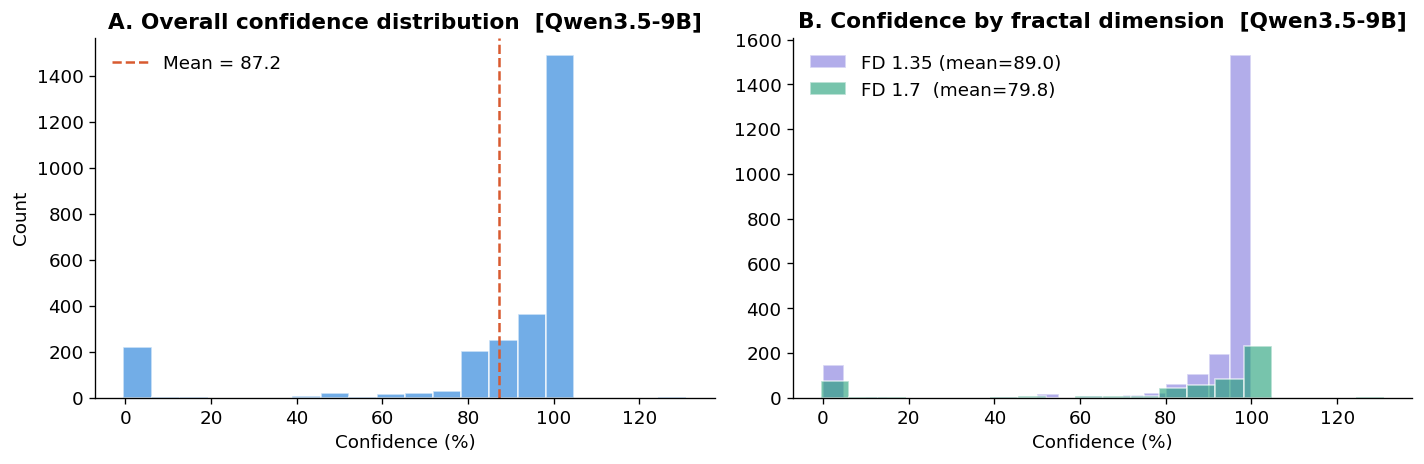

Overall:  n=2635,  mean=87.2,  median=100.0
FD 1.35:  n=2107,  mean=89.0,  median=100.0
FD 1.7:   n=528,   mean=79.8,   median=95.0


In [18]:
# ── Fig 4: Confidence distribution ──
def to_float(v):
    try: return float(v)
    except (TypeError, ValueError): return None

all_conf = [x for cs in df['confidences'] for c in cs if (x := to_float(c)) is not None]
conf_135 = [x for cs in df[df.fd=='FD135']['confidences'] for c in cs if (x := to_float(c)) is not None]
conf_17  = [x for cs in df[df.fd=='FD17' ]['confidences'] for c in cs if (x := to_float(c)) is not None]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: overall histogram
ax = axes[0]
if all_conf:
    ax.hist(all_conf, bins=20, color=BLUE, alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(all_conf), color=CORAL, linestyle='--', linewidth=1.5,
               label=f'Mean = {np.mean(all_conf):.1f}')
    ax.legend(frameon=False)
else:
    ax.text(0.5, 0.5, 'No confidence data', ha='center', va='center',
            transform=ax.transAxes, color=GRAY, fontsize=12)
ax.set_xlabel('Confidence (%)')
ax.set_ylabel('Count')
ax.set_title('A. Overall confidence distribution  [Qwen3.5-9B]')

# Panel B: by FD
ax = axes[1]
if conf_135:
    ax.hist(conf_135, bins=20, alpha=0.6, color=PURPLE,
            label=f'FD 1.35 (mean={np.mean(conf_135):.1f})', edgecolor='white')
if conf_17:
    ax.hist(conf_17, bins=20, alpha=0.6, color=TEAL,
            label=f'FD 1.7  (mean={np.mean(conf_17):.1f})',  edgecolor='white')
if not conf_135 and not conf_17:
    ax.text(0.5, 0.5, 'No confidence data', ha='center', va='center',
            transform=ax.transAxes, color=GRAY, fontsize=12)
ax.set_xlabel('Confidence (%)')
ax.set_title('B. Confidence by fractal dimension  [Qwen3.5-9B]')
ax.legend(frameon=False)

plt.tight_layout()
import os; os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(SAVE_DIR + 'fig4_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Overall:  n={len(all_conf)},  mean={np.mean(all_conf):.1f},  median={np.median(all_conf):.1f}" if all_conf else "No confidence data.")
if conf_135: print(f"FD 1.35:  n={len(conf_135)},  mean={np.mean(conf_135):.1f},  median={np.median(conf_135):.1f}")
if conf_17:  print(f"FD 1.7:   n={len(conf_17)},   mean={np.mean(conf_17):.1f},   median={np.median(conf_17):.1f}")

## 6. DAT baseline — vocabulary diversity by temperature

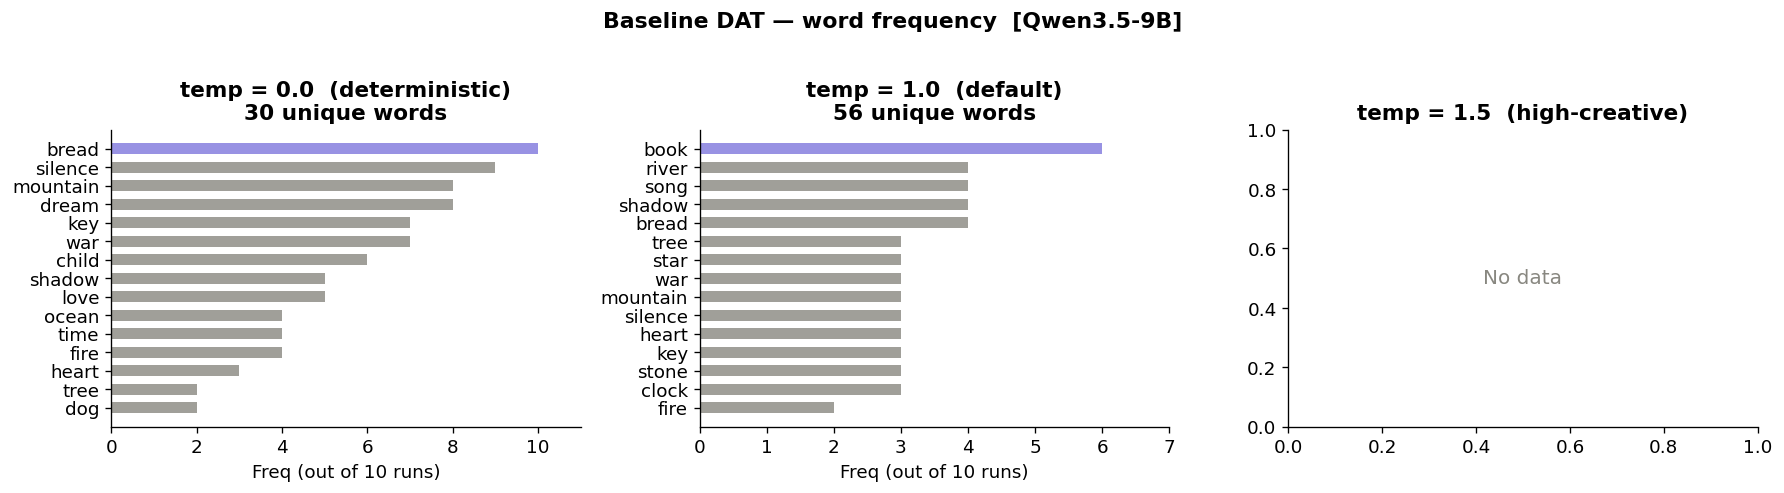

In [19]:
# ── Fig 5: Baseline DAT word frequency ──
temps_b     = sorted(df_b['temperature'].unique())
temp_names  = {0.0: 'deterministic', 1.0: 'default', 1.5: 'high-creative'}
n_runs      = df_b['run_id'].nunique()  # actual number of baseline runs

fig, axes = plt.subplots(1, len(temps_b), figsize=(5 * len(temps_b), 4))
if len(temps_b) == 1:
    axes = [axes]  # ensure iterable when only one temp

for ax, temp in zip(axes, temps_b):
    sub   = df_b[df_b.temperature == temp]
    all_w = [w for ws in sub['dat_words'] for w in ws]

    if not all_w:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, color=GRAY, fontsize=12)
        ax.set_title(f'temp = {temp}  ({temp_names.get(temp, "")})')
        continue

    wc = Counter(all_w).most_common(15)
    max_freq = max(c for _, c in wc)
    colors_bar = [PURPLE if c == max_freq else GRAY for _, c in reversed(wc)]

    ax.barh([w for w, c in reversed(wc)],
            [c for w, c in reversed(wc)],
            color=colors_bar, alpha=0.8, height=0.6)
    ax.set_title(f'temp = {temp}  ({temp_names.get(temp, "")})\n'
                 f'{len(set(all_w))} unique words')
    ax.set_xlabel(f'Freq (out of {n_runs} run{"s" if n_runs > 1 else ""})')
    ax.set_xlim(0, max_freq + 1)

plt.suptitle('Baseline DAT — word frequency  [Qwen3.5-9B]', fontweight='bold', y=1.02)
plt.tight_layout()
import os; os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(SAVE_DIR + 'fig5_baseline_dat.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Priming effect — fractal exposure expands DAT vocabulary

The key comparison: how many unique words does the model produce in DAT baseline vs after seeing a fractal?


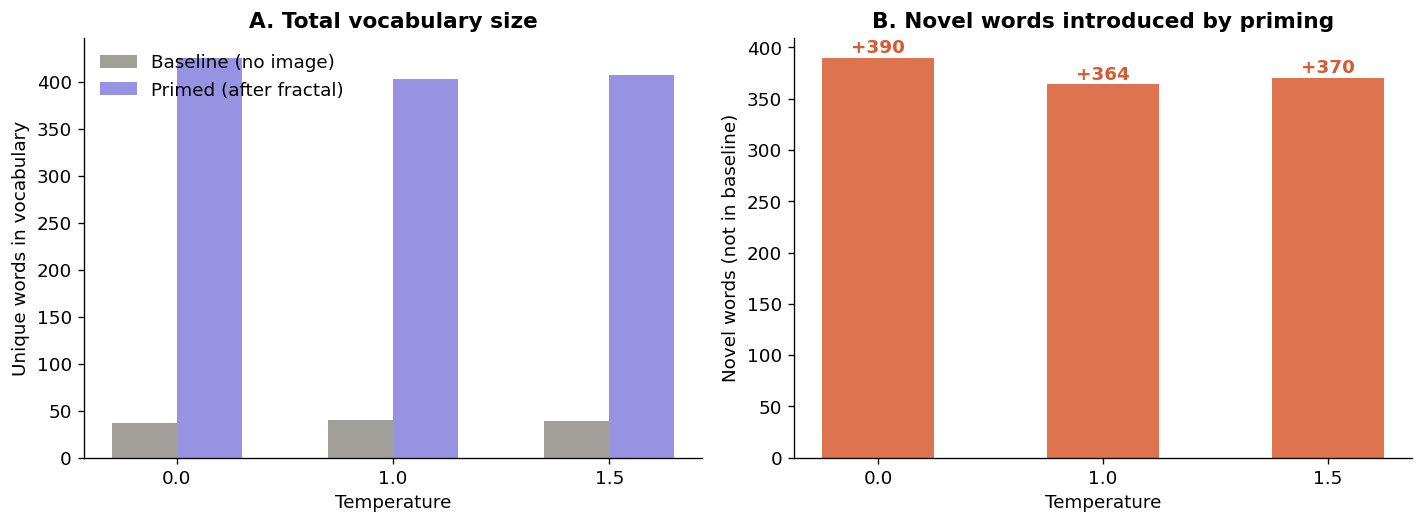

Novel words at temp=0.0 (fractal broke determinism):
  ['aardvark', 'abacus', 'accordion', 'algae', 'algorithm', 'alphabet', 'ambition', 'ancestor', 'anchor', 'ankle', 'ant', 'anvil', 'appetite', 'arithmetic', 'aroma', 'ash', 'asteroid', 'atom', 'avalanche', 'bacteria', 'badger', 'ballet', 'balloon', 'banjo', 'barn', 'beetle', 'betrayal', 'bicycle', 'biscuit', 'blanket', 'blister', 'blizzard', 'blossom', 'bread', 'breakfast', 'brick', 'butterfly', 'cabbage', 'cactus', 'calculator', 'calculus', 'calendar', 'candle', 'carbon', 'carnival', 'carousel', 'carpenter', 'carpentry', 'carpet', 'carrot', 'cathedral', 'ceiling', 'cement', 'chocolate', 'clarinet', 'clockwork', 'cloud', 'clown', 'comet', 'compass', 'compassion', 'compost', 'contract', 'copper', 'courage', 'cradle', 'cricket', 'crocodile', 'crumb', 'cucumber', 'dawn', 'desert', 'dream', 'earthquake', 'echo', 'eclipse', 'economy', 'elbow', 'elephant', 'ember', 'emerald', 'entropy', 'equation', 'equator', 'equinox', 'eternity', 'exile'

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Panel A: Vocabulary size ──
ax = axes[0]
temps = [0.0, 1.0, 1.5]
temp_names = ['0.0', '1.0', '1.5']

baseline_vocab = []
primed_vocab   = []
novel_counts   = []

for t in temps:
    b_words = set(w for _, row in df_b[df_b.temperature==t].iterrows() for w in row['dat_words'])
    p_words = set(w for _, row in df[df.temperature==t].iterrows() for w in row['dat_words'])
    baseline_vocab.append(len(b_words))
    primed_vocab.append(len(p_words))
    novel_counts.append(len(p_words - b_words))

x = np.arange(len(temps))
w = 0.3
ax.bar(x - w/2, baseline_vocab, w, color=GRAY,   alpha=0.8, label='Baseline (no image)')
ax.bar(x + w/2, primed_vocab,   w, color=PURPLE, alpha=0.8, label='Primed (after fractal)')
ax.set_xticks(x)
ax.set_xticklabels(temp_names)
ax.set_xlabel('Temperature')
ax.set_ylabel('Unique words in vocabulary')
ax.set_title('A. Total vocabulary size')
ax.legend(frameon=False)

# ── Panel B: Novel words ──
ax = axes[1]
ax.bar(temp_names, novel_counts, color=CORAL, alpha=0.85, width=0.5)
ax.set_xlabel('Temperature')
ax.set_ylabel('Novel words (not in baseline)')
ax.set_title('B. Novel words introduced by priming')

for i, v in enumerate(novel_counts):
    ax.text(i, v + 5, f'+{v}', ha='center', fontweight='bold', fontsize=11, color=CORAL)

plt.tight_layout()
plt.savefig('fig6_priming_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("Novel words at temp=0.0 (fractal broke determinism):")
b_words_0 = set(w for _, row in df_b[df_b.temperature==0.0].iterrows() for w in row['dat_words'])
p_words_0 = set(w for _, row in df[df.temperature==0.0].iterrows() for w in row['dat_words'])
novel_0 = sorted(p_words_0 - b_words_0)
print(f"  {novel_0}")


## 8. Most pareidolic images — per-image percept count

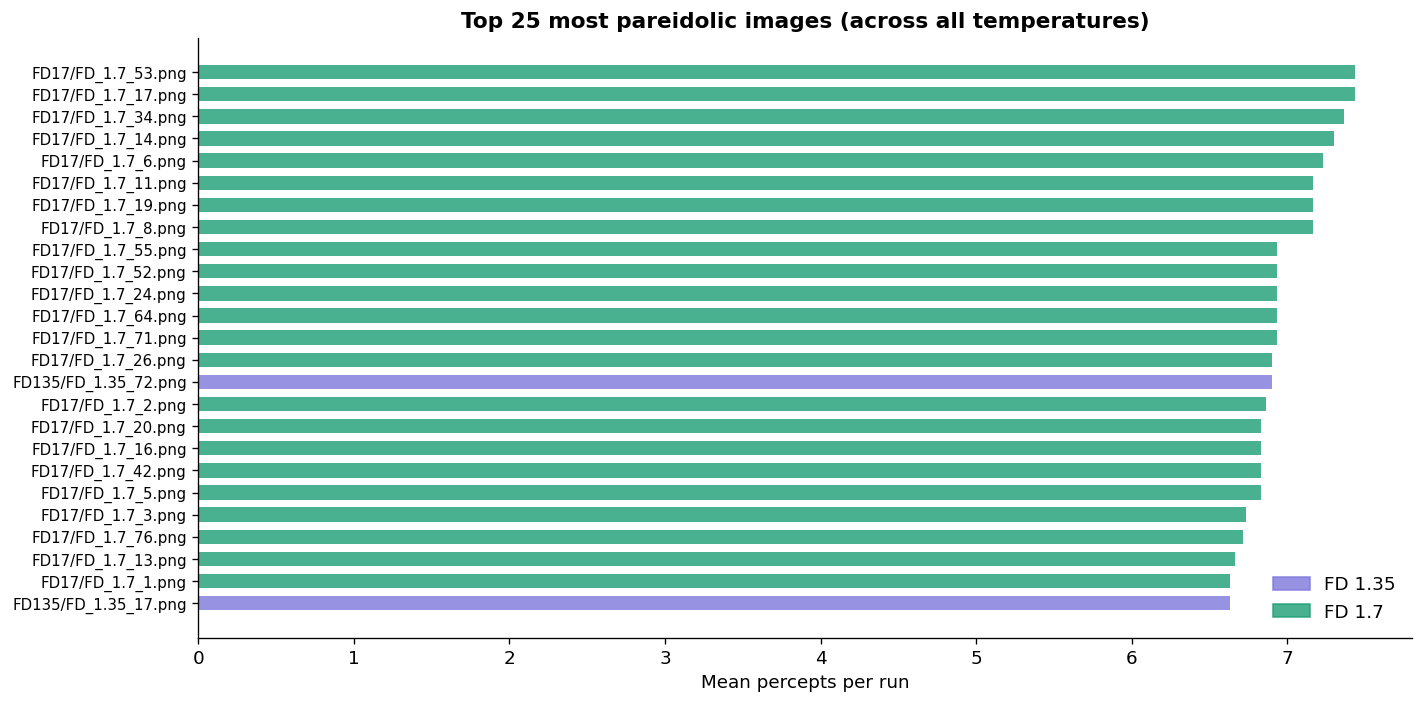


FD distribution in top 25:
fd
FD17     23
FD135     2
Name: count, dtype: int64


In [9]:
# Mean percepts per image across all temps and runs
img_stats = df.groupby(['fd', 'file']).agg(
    mean_percepts=('n_percepts', 'mean'),
    std_percepts=('n_percepts', 'std'),
    max_percepts=('n_percepts', 'max'),
    zero_rate=('n_percepts', lambda x: (x == 0).mean() * 100)
).reset_index().sort_values('mean_percepts', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_n = 25
top_imgs = img_stats.head(top_n)

colors = [PURPLE if fd == 'FD135' else TEAL for fd in top_imgs['fd']]
bars = ax.barh(range(top_n), top_imgs['mean_percepts'].values, color=colors, alpha=0.8, height=0.65)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"{row.fd}/{row.file}" for _, row in top_imgs.iterrows()], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean percepts per run')
ax.set_title(f'Top {top_n} most pareidolic images (across all temperatures)')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=PURPLE, alpha=0.8, label='FD 1.35'),
                   Patch(color=TEAL,   alpha=0.8, label='FD 1.7')],
          frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig('fig7_top_images.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFD distribution in top {top_n}:")
print(top_imgs['fd'].value_counts())


## 9. Latency analysis

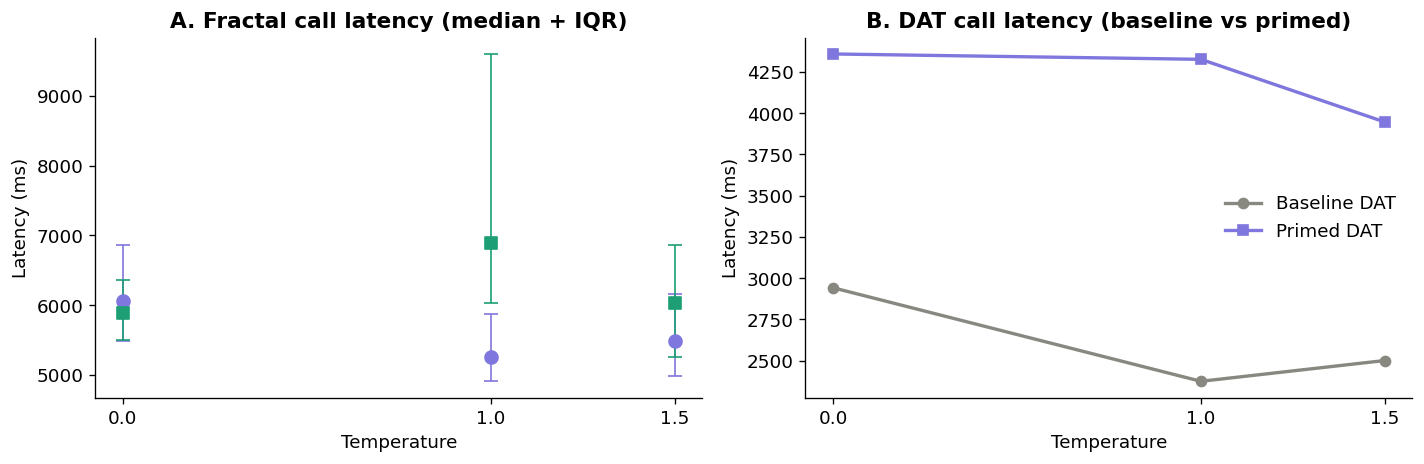

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fractal latency
ax = axes[0]
for fd, color in [('FD135', PURPLE), ('FD17', TEAL)]:
    for temp in [0.0, 1.0, 1.5]:
        sub = df[(df.fd==fd) & (df.temperature==temp)]
        ax.scatter(temp, sub['ms_fractal'].median(), color=color, s=60, zorder=5,
                   marker='o' if fd=='FD135' else 's')
        ax.errorbar(temp, sub['ms_fractal'].median(),
                    yerr=[[sub['ms_fractal'].median() - sub['ms_fractal'].quantile(0.25)],
                          [sub['ms_fractal'].quantile(0.75) - sub['ms_fractal'].median()]],
                    color=color, capsize=4, linewidth=1)
ax.set_xlabel('Temperature')
ax.set_ylabel('Latency (ms)')
ax.set_title('A. Fractal call latency (median + IQR)')
ax.set_xticks([0.0, 1.0, 1.5])

# DAT latency
ax = axes[1]
baseline_lat = [df_b[df_b.temperature==t]['ms'].median() for t in [0.0, 1.0, 1.5]]
primed_lat   = [df[df.temperature==t]['ms_dat'].median() for t in [0.0, 1.0, 1.5]]

ax.plot([0.0, 1.0, 1.5], baseline_lat, 'o-', color=GRAY,   label='Baseline DAT', linewidth=2)
ax.plot([0.0, 1.0, 1.5], primed_lat,   's-', color=PURPLE, label='Primed DAT',   linewidth=2)
ax.set_xlabel('Temperature')
ax.set_ylabel('Latency (ms)')
ax.set_title('B. DAT call latency (baseline vs primed)')
ax.legend(frameon=False)
ax.set_xticks([0.0, 1.0, 1.5])

plt.tight_layout()
plt.savefig('fig8_latency.png', dpi=150, bbox_inches='tight')
plt.show()
